# Apple Stock Analysis (AAPL)

Professional exploratory analysis of Apple Inc. market behavior using historical price data and company metadata.

## Objectives
- Load and validate Apple company metadata from a local JSON file.
- Retrieve full historical AAPL price data via `yfinance`.
- Perform quality checks and descriptive analysis.
- Visualize trends in price, volume, returns, and volatility.
- Engineer moving-average and risk-related features for interpretation.

## 1. Environment Setup

Import required libraries and configure plotting defaults for readability.

In [3]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

In [4]:
# Initialize a Ticker object for Apple Inc.
apple = yf.Ticker("AAPL")

In [ ]:
# Optional: Use this block only if `../data/raw/apple.json` is missing.
# import urllib.request
#
# url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/data/apple.json"
# urllib.request.urlretrieve(url, "../data/raw/apple.json")

('../data/raw/apple.json', <http.client.HTTPMessage at 0x26dd29f0ce0>)

## 2. Load Company Metadata

Read static company metadata from the local project dataset and inspect key fields.

In [5]:
data_path = Path("../data/raw/apple.json")

with data_path.open("r", encoding="utf-8") as json_file:
    apple_info = json.load(json_file)

# Show a concise metadata snapshot
metadata_fields = [
    "symbol",
    "shortName",
    "sector",
    "industry",
    "marketCap",
    "currency",
    "currentPrice",
    "website",
]

{k: apple_info.get(k) for k in metadata_fields}

{'symbol': 'AAPL',
 'shortName': 'Apple Inc.',
 'sector': 'Technology',
 'industry': 'Consumer Electronics',
 'marketCap': 2901099675648,
 'currency': 'USD',
 'currentPrice': 177.77,
 'website': 'https://www.apple.com'}

## 3. Retrieve Historical Price Data

Download full historical OHLCV data for AAPL and prepare it for time-series analysis.

In [6]:
# Retrieve full historical stock price data for Apple
apple_share_price_data = apple.history(period="max").reset_index()

# Quick shape check
apple_share_price_data.shape

(11414, 8)

## 4. Data Quality and Summary Statistics

Validate completeness and inspect baseline statistical behavior of core numeric variables.

In [7]:
# Missing-value audit
apple_share_price_data.isnull().sum().sort_values(ascending=False)

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [8]:
apple_share_price_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1980-12-12 00:00:00-05:00,0.098297,0.098725,0.098297,0.098297,469033600,0.0,0.0
1,1980-12-15 00:00:00-05:00,0.093597,0.093597,0.093169,0.093169,175884800,0.0,0.0
2,1980-12-16 00:00:00-05:00,0.086758,0.086758,0.086331,0.086331,105728000,0.0,0.0
3,1980-12-17 00:00:00-05:00,0.088468,0.088895,0.088468,0.088468,86441600,0.0,0.0
4,1980-12-18 00:00:00-05:00,0.091032,0.091460,0.091032,0.091032,73449600,0.0,0.0


In [9]:
# Date coverage of the historical dataset
apple_share_price_data["Date"].min(), apple_share_price_data["Date"].max()

(Timestamp('1980-12-12 00:00:00-0500', tz='America/New_York'),
 Timestamp('2026-03-27 00:00:00-0400', tz='America/New_York'))

In [10]:
apple_share_price_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,11414.0,2.912066e+01,5.993981e+01,0.038037,2.468386e-01,4.946894e-01,2.189335e+01,2.859325e+02
High,11414.0,2.943526e+01,6.057997e+01,0.038037,2.536790e-01,5.029129e-01,2.216309e+01,2.883502e+02
Low,11414.0,2.882342e+01,5.934506e+01,0.037609,2.415074e-01,4.848223e-01,2.171215e+01,2.830352e+02
Close,11414.0,2.914109e+01,5.998569e+01,0.037609,2.472461e-01,4.939418e-01,2.189473e+01,2.859225e+02
Volume,11414.0,3.083787e+08,3.330736e+08,0.000000,1.053752e+08,1.972376e+08,3.885208e+08,7.421641e+09
Dividends,11414.0,8.816860e-04,1.315252e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.600000e-01
Stock Splits,11414.0,1.489399e-03,8.212475e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00


## 5. Price, Volume, and Dividend Visualization

Build core exploratory charts to understand long-term movement in price, volume, and dividend history.

<Axes: title={'center': 'Apple Stock Opening Prices Over Time'}, xlabel='Date', ylabel='Price (USD)'>

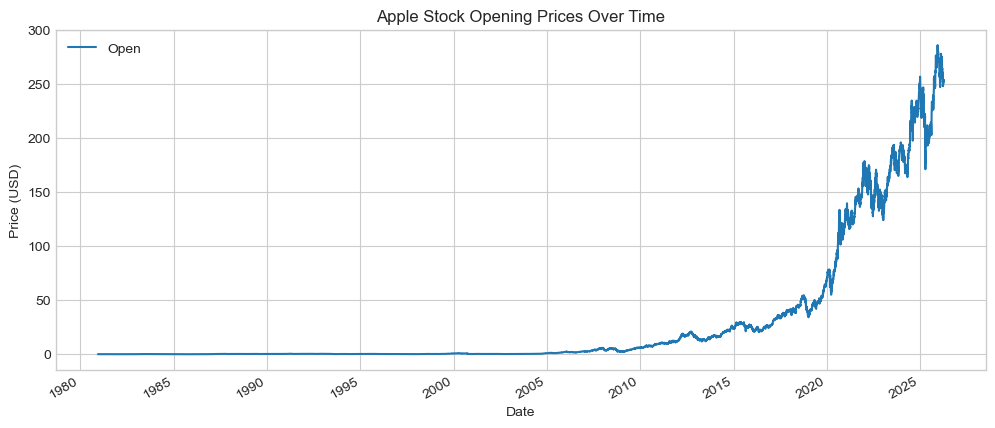

In [11]:
apple_share_price_data.plot(
    x="Date",
    y="Open",
    figsize=(12, 5),
    title="Apple Stock Opening Prices Over Time",
    ylabel="Price (USD)",
)

<Axes: title={'center': 'Apple Stock Closing Price Over Time'}, xlabel='Date', ylabel='Price (USD)'>

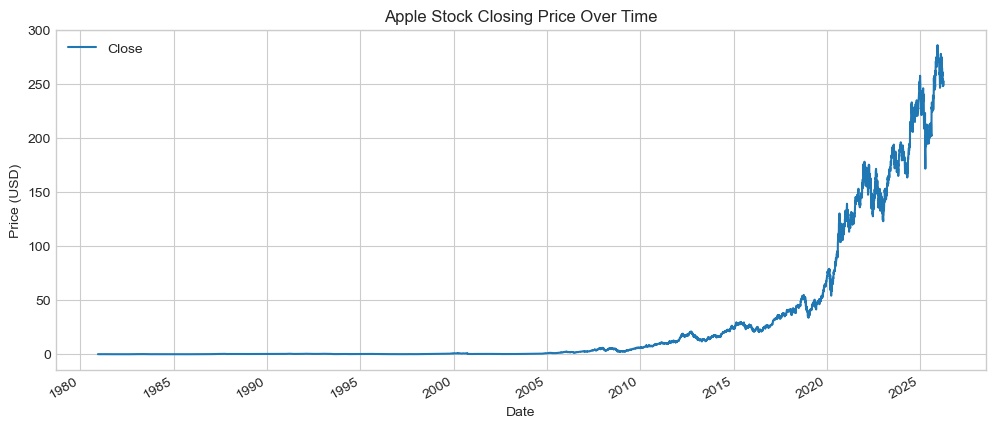

In [12]:
apple_share_price_data.plot(
    x="Date",
    y="Close",
    figsize=(12, 5),
    title="Apple Stock Closing Price Over Time",
    ylabel="Price (USD)",
)

In [13]:
# Most recent dividend records
apple.dividends.tail(10)

Date
2023-11-10 00:00:00-05:00    0.24
2024-02-09 00:00:00-05:00    0.24
2024-05-10 00:00:00-04:00    0.25
2024-08-12 00:00:00-04:00    0.25
2024-11-08 00:00:00-05:00    0.25
2025-02-10 00:00:00-05:00    0.25
2025-05-12 00:00:00-04:00    0.26
2025-08-11 00:00:00-04:00    0.26
2025-11-10 00:00:00-05:00    0.26
2026-02-09 00:00:00-05:00    0.26
Name: Dividends, dtype: float64

<Axes: title={'center': 'Apple Dividend History Over Time'}, xlabel='Date', ylabel='Dividend (USD)'>

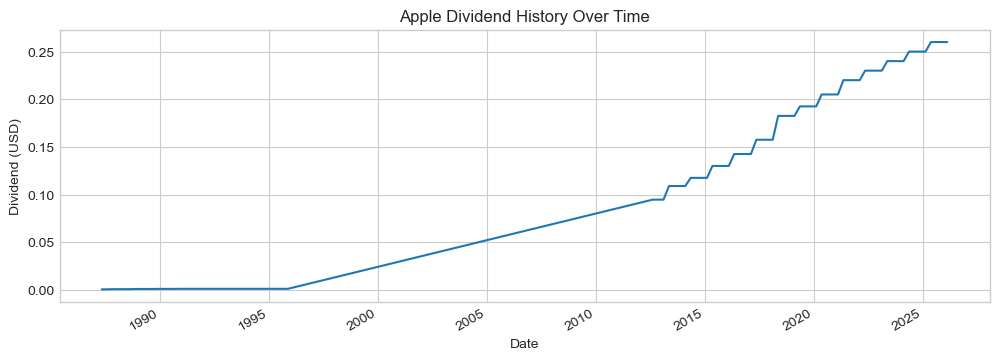

In [14]:
apple.dividends.plot(
    figsize=(12, 4),
    title="Apple Dividend History Over Time",
    ylabel="Dividend (USD)",
)

<Axes: title={'center': 'Apple Stock Trading Volume Over Time'}, xlabel='Date', ylabel='Volume'>

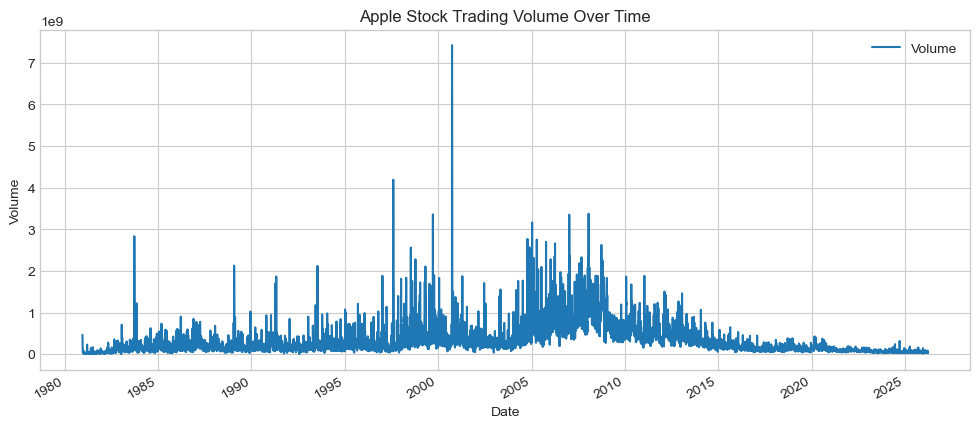

In [15]:
apple_share_price_data.plot(
    x="Date",
    y="Volume",
    figsize=(12, 5),
    title="Apple Stock Trading Volume Over Time",
    ylabel="Volume",
)

## 6. Feature Engineering and Return Analysis

Create technical indicators and return-based measures to assess trend and short-term risk behavior.

In [16]:
# 20-day Simple Moving Average
apple_share_price_data["SMA_20"] = apple_share_price_data["Close"].rolling(window=20).mean()

<Axes: title={'center': 'Apple Close Price and 20-Day SMA'}, xlabel='Date', ylabel='Price (USD)'>

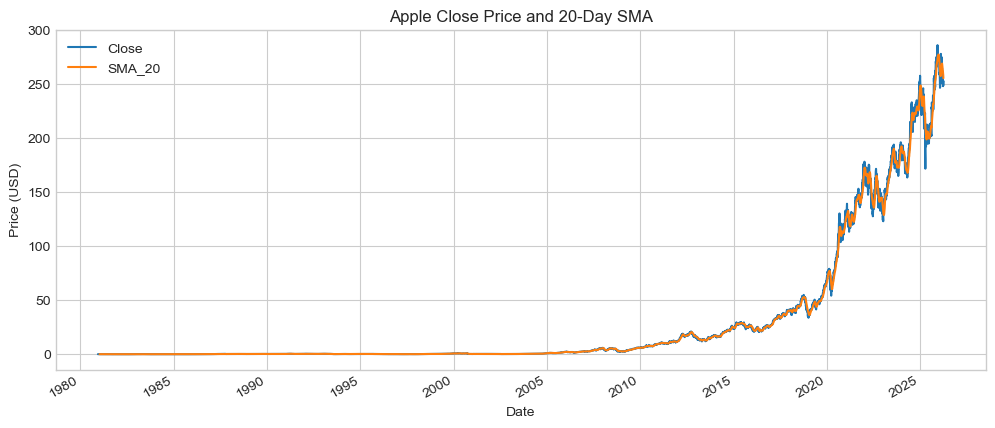

In [17]:
apple_share_price_data.plot(
    x="Date",
    y=["Close", "SMA_20"],
    figsize=(12, 5),
    title="Apple Close Price and 20-Day SMA",
    ylabel="Price (USD)",
)

In [18]:
# Daily return as percentage change in close price
apple_share_price_data["Daily_Return"] = apple_share_price_data["Close"].pct_change()

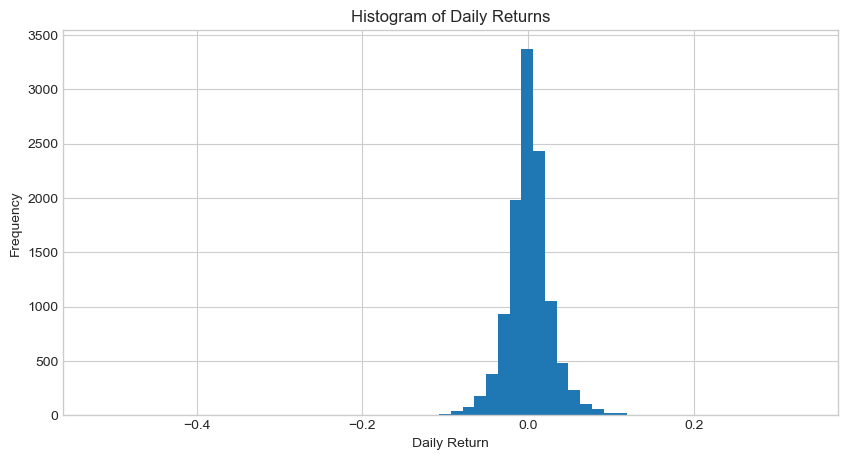

In [19]:
apple_share_price_data["Daily_Return"].hist(bins=60, figsize=(10, 5))
plt.title("Histogram of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [20]:
apple_share_price_data["MA20"] = apple_share_price_data["Close"].rolling(window=20).mean()
apple_share_price_data["MA50"] = apple_share_price_data["Close"].rolling(window=50).mean()

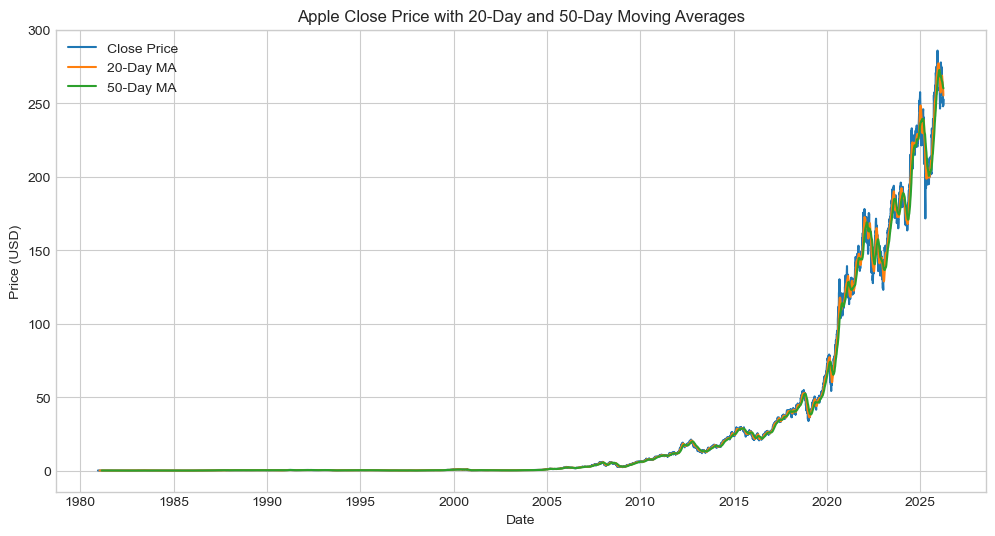

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(apple_share_price_data["Date"], apple_share_price_data["Close"], label="Close Price")
plt.plot(apple_share_price_data["Date"], apple_share_price_data["MA20"], label="20-Day MA")
plt.plot(apple_share_price_data["Date"], apple_share_price_data["MA50"], label="50-Day MA")
plt.title("Apple Close Price with 20-Day and 50-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

## 7. Rolling Volatility

Estimate short-term risk using rolling 20-day standard deviation of daily returns.

In [22]:
apple_share_price_data["Volatility_20d"] = apple_share_price_data["Daily_Return"].rolling(window=20).std()

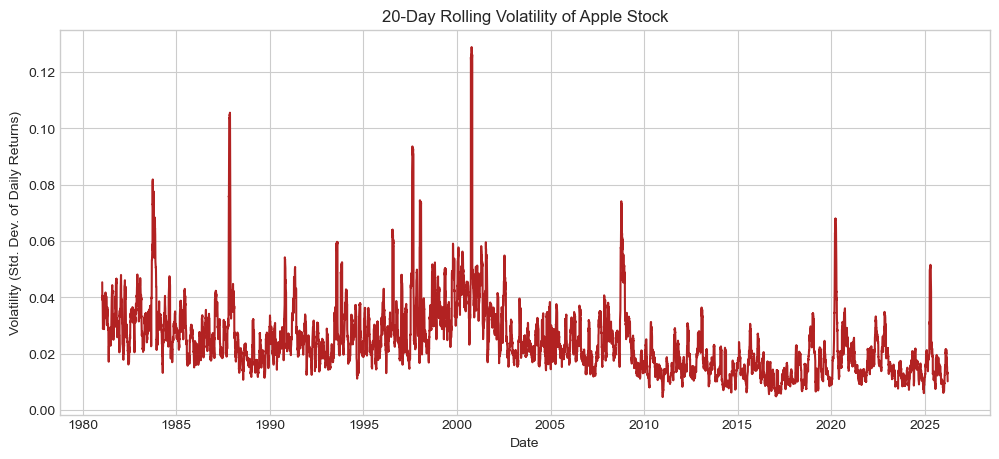

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(apple_share_price_data["Date"], apple_share_price_data["Volatility_20d"], color="firebrick")
plt.title("20-Day Rolling Volatility of Apple Stock")
plt.xlabel("Date")
plt.ylabel("Volatility (Std. Dev. of Daily Returns)")
plt.show()

## 8. Key Takeaways

- Apple shows a strong long-term upward trend in closing prices, with periodic drawdowns.
- Daily returns are centered near zero with a heavy-tailed distribution, indicating occasional large moves.
- Moving averages smooth noise and make medium-term trend shifts easier to interpret.
- Rolling 20-day volatility highlights clusters of elevated uncertainty.

